<a href="https://colab.research.google.com/github/kripaapalaniappan/Cyberbullying-Detection-ML/blob/main/copy_of_untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/Cyberbullying_Project"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive

drive.flush_and_unmount()
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import os

DATA_DIR = "/content/drive/MyDrive/Cyberbullying_Project"

print("Folder exists:", os.path.exists(DATA_DIR))
print(os.listdir(DATA_DIR))

Folder exists: True
['xlm_roberta_cyberbullying', 'telugu_train.csv', 'xlm_roberta_checkpoints', 'CyberbullyX-63K.xlsx', 'malyalam_train.csv', 'hindi_test.csv', 'hindi_train.csv', 'validation_final.csv', 'multilingual_dataset.csv', 'tamil_test.csv', 'malyalam_test.csv', 'test_final.csv', 'xlm_roberta_v2_checkpoints', 'kannada_train.csv', 'multilingual_dataset_with_synthetic.csv', 'malyalam_val.csv', 'kannada_val.csv', 'telugu_val.csv', 'tamil_train.csv', 'README.md', 'kannada_test.csv', 'telugu_test.csv', 'train_final.csv', 'hindi_val.csv', 'tamil_val.csv', 'english_clean.csv']


In [ ]:
import os

DATA_DIR = "/content/drive/MyDrive/Cyberbullying_Project"

print(os.path.exists(DATA_DIR))
print(os.listdir(DATA_DIR))

True
['xlm_roberta_cyberbullying', 'telugu_train.csv', 'xlm_roberta_checkpoints', 'CyberbullyX-63K.xlsx', 'malyalam_train.csv', 'hindi_test.csv', 'hindi_train.csv', 'validation_final.csv', 'multilingual_dataset.csv', 'tamil_test.csv', 'malyalam_test.csv', 'test_final.csv', 'xlm_roberta_v2_checkpoints', 'kannada_train.csv', 'multilingual_dataset_with_synthetic.csv', 'malyalam_val.csv', 'kannada_val.csv', 'telugu_val.csv', 'tamil_train.csv', 'README.md', 'kannada_test.csv', 'telugu_test.csv', 'train_final.csv', 'hindi_val.csv', 'tamil_val.csv', 'english_clean.csv']


In [ ]:
import os

files = os.listdir("/content")

for file in files:
    if file.endswith(".csv") or file.endswith(".xlsx"):
        print(file)

In [ ]:
import os

for file in os.listdir("/content"):
    if file.endswith(".csv") or file.endswith(".xlsx"):
        size_mb = os.path.getsize("/content/" + file) / (1024 * 1024)
        print(f"{file:45} {size_mb:.2f} MB")

In [ ]:
import pandas as pd
import os

DATA_DIR = "/content/drive/MyDrive/Cyberbullying_Project"

# Load every dataset
all_data = {}

for file in os.listdir(DATA_DIR):
    path = os.path.join(DATA_DIR, file)

    if file.endswith(".csv"):
        try:
            df = pd.read_csv(path)
            all_data[file] = df
        except Exception as e:
            print(f"Could not read {file}: {e}")

    elif file.endswith(".xlsx"):
        try:
            df = pd.read_excel(path)
            all_data[file] = df
        except Exception as e:
            print(f"Could not read {file}: {e}")

print("\nDATASETS LOADED")
print("=" * 60)

for name, df in all_data.items():
    print(f"{name:45} {df.shape}")


DATASETS LOADED
telugu_train.csv                              (18000, 2)
CyberbullyX-63K.xlsx                          (63145, 5)
malyalam_train.csv                            (15508, 2)
hindi_test.csv                                (6728, 2)
hindi_train.csv                               (20183, 2)
validation_final.csv                          (58688, 6)
multilingual_dataset.csv                      (221511, 3)
tamil_test.csv                                (6000, 2)
malyalam_test.csv                             (5170, 2)
test_final.csv                                (58684, 6)
kannada_train.csv                             (19761, 2)
multilingual_dataset_with_synthetic.csv       (219659, 5)
malyalam_val.csv                              (5170, 2)
kannada_val.csv                               (6587, 2)
telugu_val.csv                                (6000, 2)
tamil_train.csv                               (18000, 2)
kannada_test.csv                              (6587, 2)
telugu_test.csv    

In [ ]:
for name, df in all_data.items():
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    print("Columns:")
    print(list(df.columns))

    print("\nFirst 3 rows:")
    display(df.head(3))

In [ ]:
for name, df in all_data.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Rows:", len(df))
    print("Columns:", list(df.columns))

    # Show unique values for columns with few unique values
    for col in df.columns:
        if df[col].nunique(dropna=False) <= 20:
            print(f"\n{col} values:")
            print(df[col].value_counts(dropna=False))

In [ ]:
import os
import pandas as pd

# Google Drive dataset folder
DATA_DIR = "/content/drive/MyDrive/Cyberbullying_Project"

# Files to inspect
important_files = [
    "CyberbullyX-63K.xlsx",
    "english_clean.csv",
    "multilingual_dataset.csv",
    "multilingual_dataset_with_synthetic.csv"
]

# Make sure the folder exists
if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(
        f"Dataset folder not found: {DATA_DIR}"
    )

# Load the datasets into all_data
all_data = {}

for name in important_files:

    file_path = os.path.join(DATA_DIR, name)

    if not os.path.exists(file_path):
        print(f"⚠️ File not found: {name}")
        continue

    if name.endswith(".xlsx"):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path)

    all_data[name] = df

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Shape:", df.shape)
    print("Columns:", list(df.columns))

    for col in df.columns:
        print(f"\nColumn: {col}")
        print("Unique values:", df[col].nunique())
        print(df[col].value_counts(dropna=False).head(20))


CyberbullyX-63K.xlsx
Shape: (63145, 5)
Columns: ['tweet_id', 'date', 'lang', 'text', 'final_label']

Column: tweet_id
Unique values: 63145
tweet_id
2053979333765513416    1
1278039274991075329    1
1277913148163420165    1
1277821777154990080    1
1277821301806125057    1
1277649641165611009    1
1277638488083460102    1
1277578597243301888    1
1277240810489118720    1
2053979407119712301    1
2053979404397584616    1
2053979404359844325    1
2053979401532907585    1
2053979401381933272    1
2053979400463327559    1
2053979399897133373    1
2053979398508851702    1
2053979417769046191    1
2053979417194467439    1
2053979416456479054    1
Name: count, dtype: int64

Column: date
Unique values: 52067
date
2026-04-07 23:54:31+00:00    14
2026-04-07 23:57:41+00:00    13
2026-04-07 23:59:38+00:00    11
2026-04-07 23:57:34+00:00    11
2026-04-07 23:54:50+00:00    10
2026-04-07 23:56:27+00:00    10
2026-04-07 23:54:06+00:00    10
2026-04-07 23:56:04+00:00    10
2026-04-07 23:59:13+00:00    

In [ ]:
# ============================================
# CHECK DUPLICATES BETWEEN OUR DATASETS
# ============================================

import pandas as pd

df_multi = all_data["multilingual_dataset.csv"].copy()
df_multi_syn = all_data["multilingual_dataset_with_synthetic.csv"].copy()

# Convert text to string
df_multi["text"] = df_multi["text"].astype(str).str.strip()
df_multi_syn["text"] = df_multi_syn["text"].astype(str).str.strip()

# Exact duplicate text counts
multi_texts = set(df_multi["text"])
multi_syn_texts = set(df_multi_syn["text"])

overlap = multi_texts.intersection(multi_syn_texts)

print("multilingual_dataset rows:",
      len(df_multi))

print("multilingual_dataset_with_synthetic rows:",
      len(df_multi_syn))

print("Unique texts in multilingual_dataset:",
      len(multi_texts))

print("Unique texts in multilingual_dataset_with_synthetic:",
      len(multi_syn_texts))

print("Exact overlapping texts:",
      len(overlap))

print("Overlap percentage relative to multilingual_dataset:",
      round(len(overlap) / len(multi_texts) * 100, 2), "%")

multilingual_dataset rows: 221511
multilingual_dataset_with_synthetic rows: 219659
Unique texts in multilingual_dataset: 219568
Unique texts in multilingual_dataset_with_synthetic: 219621
Exact overlapping texts: 219568
Overlap percentage relative to multilingual_dataset: 100.0 %


In [ ]:
# ============================================
# CHECK DUPLICATES ACROSS ALL DATASETS
# ============================================

from collections import defaultdict

text_sources = defaultdict(list)

for name, df in all_data.items():

    if "text" in df.columns:

        for text in df["text"].dropna().astype(str).str.strip():
            text_sources[text].append(name)

duplicate_texts = {
    text: sources
    for text, sources in text_sources.items()
    if len(sources) > 1
}

print("Total unique texts:",
      len(text_sources))

print("Texts appearing in multiple datasets:",
      len(duplicate_texts))

# Show a few examples
print("\nExamples of cross-dataset duplicates:\n")

for i, (text, sources) in enumerate(duplicate_texts.items()):

    print("TEXT:", text[:200])
    print("DATASETS:", sources)
    print("-" * 80)

    if i >= 9:
        break

Total unique texts: 282358
Texts appearing in multiple datasets: 219685

Examples of cross-dataset duplicates:

TEXT: BHARTI #RADIOGRAPHER_LAB_TECHNICIAN JALDI SE PURI KRE SARKAR  #Congress_sarkar 8 mahine se berozegaron ko pagal bna rhi hai 😡😡 #भर्ती_रेडियोग्राफर_लैब_टेक्नीशियन @RaghusharmaINC @ashokgehlot51 @TheUpe
DATASETS: ['CyberbullyX-63K.xlsx', 'CyberbullyX-63K.xlsx']
--------------------------------------------------------------------------------
TEXT: OverActing Ki Dukan #RheaChakrobarty ! @sardesairajdeep Idiot What Will Be Your Thinking If Your Son Faces Those Challenges That #ShushantSinghRajput Faced Till June 14th ! Shame ! Shame !  @Tweet2Rhe
DATASETS: ['CyberbullyX-63K.xlsx', 'CyberbullyX-63K.xlsx']
--------------------------------------------------------------------------------
TEXT: The movie Which will Remain as most fav Film to @RaviTeja_offl fans and movie lovers ♥️  Here's is the tag To celebrate the 18th Anniversary of #Idiot  Tag - 👉  #18YearsForIDIOT  👈  Let's 

In [ ]:
# ============================================
# CHECK SAMPLE TEXTS FOR EVERY LABEL
# ============================================

import os
import pandas as pd

# Google Drive dataset folder
DATA_DIR = "/content/drive/MyDrive/Cyberbullying_Project"

files_to_check = [
    "CyberbullyX-63K.xlsx",
    "english_clean.csv",
    "multilingual_dataset.csv",
    "hindi_train.csv",
    "tamil_train.csv",
    "telugu_train.csv",
    "kannada_train.csv",
    "malyalam_train.csv"
]

# Load files from Google Drive
all_data = {}

for name in files_to_check:

    file_path = os.path.join(DATA_DIR, name)

    if not os.path.exists(file_path):
        print(f"⚠️ File not found: {name}")
        continue

    # Read Excel or CSV
    if name.endswith(".xlsx"):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path)

    all_data[name] = df


# ============================================
# DISPLAY SAMPLE TEXTS FOR EVERY LABEL
# ============================================

for name in files_to_check:

    if name not in all_data:
        continue

    df = all_data[name]

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    # Determine label column
    if "final_label" in df.columns:
        label_col = "final_label"
    else:
        label_col = "label"

    for label in df[label_col].dropna().unique():

        print(f"\n--- LABEL: {label} ---")

        sample = (
            df[df[label_col] == label]["text"]
            .dropna()
            .head(3)
        )

        for text in sample:
            print("•", str(text)[:300].replace("\n", " "))


CyberbullyX-63K.xlsx

--- LABEL: 1 ---
• Say this to everyone who thinks that it’s ok to judge anyone or u without knowing u . Yeh khas judgemental aur narrsistic ppl ke liye hai . Shut up you idiot https://t.co/sfDMDfpyhx
• One word for this chutiya Guswami 😂 #ArnabGoswami https://t.co/ojXbDSNgTB
• Ye hutiyapa he. NO ITS THERE. YE SARE MILKE HUMKO PAGAL BANA RAHE HAIN . https://t.co/KyMrx55Y4B https://t.co/Rfln2DlcJR

--- LABEL: 0 ---
• Joined Tribe Membership 😊 @BewakoofBrands #bewakoof #tribemember https://t.co/uMr6ERMJ04
• I will purchase d mobile.but technical problem k karan mjhko isse replace karna tha.@Flipkart @flipkartsupport owners of @sachinbansal @binnybansal  Apki company ne behan chhod chutiya bana rkha h.aaj 14 days ho gye..bs 48 hours chuna lga dete hain.@TataCLiQ @amazonIN is best https://t.co/GbQAX04ie2
• She is spiritually connected to Durga  , kids harass her for being abusive and mad.  But she gets along with me she carries a mobile phone and complains to #Modiji

In [ ]:
# ============================================================
# STEP: STANDARDIZE ALL DATASETS
# Final format:
# text | label | language | synthetic | source | split
# ============================================================

import pandas as pd
import numpy as np
import os

# ============================================================
# GOOGLE DRIVE DATASET LOCATION
# ============================================================

DATA_DIR = "/content/drive/MyDrive/Cyberbullying_Project"

# Make sure Drive folder exists
if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(
        f"Dataset folder not found: {DATA_DIR}"
    )

# ============================================================
# LOAD ALL REQUIRED DATASETS
# ============================================================

required_files = [
    "CyberbullyX-63K.xlsx",
    "english_clean.csv",
    "multilingual_dataset.csv",
    "multilingual_dataset_with_synthetic.csv",

    "hindi_train.csv",
    "hindi_val.csv",
    "hindi_test.csv",

    "tamil_train.csv",
    "tamil_val.csv",
    "tamil_test.csv",

    "telugu_train.csv",
    "telugu_val.csv",
    "telugu_test.csv",

    "kannada_train.csv",
    "kannada_val.csv",
    "kannada_test.csv",

    "malyalam_train.csv",
    "malyalam_val.csv",
    "malyalam_test.csv"
]

all_data = {}

print("Loading datasets from Google Drive...\n")

for filename in required_files:

    file_path = os.path.join(DATA_DIR, filename)

    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"Dataset not found: {file_path}"
        )

    if filename.endswith(".xlsx"):
        all_data[filename] = pd.read_excel(file_path)
    else:
        all_data[filename] = pd.read_csv(file_path)

    print(
        f"{filename:45} "
        f"{len(all_data[filename]):>8,} rows"
    )

print("\nAll datasets loaded successfully!")


# ============================================================
# STANDARDIZATION
# ============================================================

standardized = []


# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def add_dataset(df, source, language, label_mapping,
                label_column="label",
                split="unsplit",
                synthetic=0):

    temp = df.copy()

    temp = temp.rename(columns={
        label_column: "original_label"
    })

    temp["text"] = temp["text"].astype(str).str.strip()

    # Apply label mapping
    temp["label"] = temp["original_label"].map(label_mapping)

    temp["language"] = language
    temp["synthetic"] = synthetic
    temp["source"] = source
    temp["split"] = split

    # Keep only required columns
    temp = temp[
        ["text", "label", "language", "synthetic", "source", "split"]
    ]

    standardized.append(temp)


# ============================================================
# 1. CYBERBULLYX-63K
# ============================================================

df = all_data["CyberbullyX-63K.xlsx"].copy()

# Keep only English and Hindi
df = df[df["lang"].isin(["en", "hi"])].copy()

df["language"] = df["lang"].map({
    "en": "English",
    "hi": "Hindi"
})

df["text"] = df["text"].astype(str).str.strip()

df["label"] = df["final_label"]

df["synthetic"] = 0
df["source"] = "CyberbullyX-63K"
df["split"] = "unsplit"

cyberbullyx = df[
    ["text", "label", "language", "synthetic", "source", "split"]
].copy()

standardized.append(cyberbullyx)

print("\nCyberbullyX prepared:", len(cyberbullyx))


# ============================================================
# 2. ENGLISH CLEAN
# ============================================================

df = all_data["english_clean.csv"].copy()

english_mapping = {
    "Normal": 0,
    "Offensive": 1,
    "Targeted_Individual": 1,
    "Identity_Hate": 1,
    "Threat": 1
}

add_dataset(
    df=df,
    source="english_clean",
    language="English",
    label_mapping=english_mapping,
    label_column="label",
    split="unsplit",
    synthetic=0
)

print("English dataset prepared:", len(df))


# ============================================================
# 3. MULTILINGUAL DATASET
# ============================================================

df = all_data["multilingual_dataset.csv"].copy()

multi_mapping = {
    "Normal": 0,
    "Offensive": 1,
    "Targeted_Individual": 1,
    "Targeted_Group": 1,
    "Identity_Hate": 1,
    "Targeted_Other": 1,
    "Threat": 1
}

for language in ["English", "Tamil", "Malayalam", "Kannada"]:

    subset = df[df["language"] == language].copy()

    add_dataset(
        df=subset,
        source="multilingual_dataset",
        language=language,
        label_mapping=multi_mapping,
        label_column="label",
        split="unsplit",
        synthetic=0
    )

print("Multilingual dataset prepared:", len(df))


# ============================================================
# 4. MULTILINGUAL DATASET WITH SYNTHETIC
# ============================================================

df = all_data["multilingual_dataset_with_synthetic.csv"].copy()

for language in ["English", "Tamil", "Malayalam", "Kannada"]:

    subset = df[df["language"] == language].copy()

    # Preserve actual synthetic flag
    original_synthetic = subset["synthetic"].values

    add_dataset(
        df=subset,
        source="multilingual_dataset_with_synthetic",
        language=language,
        label_mapping=multi_mapping,
        label_column="label",
        split="unsplit",
        synthetic=0
    )

    # Replace synthetic column with original information
    standardized[-1]["synthetic"] = original_synthetic


print(
    "Multilingual + synthetic prepared:",
    len(df)
)


# ============================================================
# 5. MACD DATASETS
# ============================================================

# IMPORTANT:
# MACD:
# 0 = abusive
# 1 = non-abusive
#
# Our final:
# 0 = non-bullying
# 1 = bullying/abusive
#
# Therefore we REVERSE the labels.

macd_mapping = {
    0: 1,
    1: 0
}


macd_files = {

    "Hindi": [
        "hindi_train.csv",
        "hindi_val.csv",
        "hindi_test.csv"
    ],

    "Tamil": [
        "tamil_train.csv",
        "tamil_val.csv",
        "tamil_test.csv"
    ],

    "Telugu": [
        "telugu_train.csv",
        "telugu_val.csv",
        "telugu_test.csv"
    ],

    "Kannada": [
        "kannada_train.csv",
        "kannada_val.csv",
        "kannada_test.csv"
    ],

    "Malayalam": [
        "malyalam_train.csv",
        "malyalam_val.csv",
        "malyalam_test.csv"
    ]
}


for language, files in macd_files.items():

    for filename in files:

        df = all_data[filename].copy()

        if "train" in filename:
            split = "train"

        elif "val" in filename:
            split = "validation"

        elif "test" in filename:
            split = "test"

        else:
            split = "unsplit"

        add_dataset(
            df=df,
            source="MACD",
            language=language,
            label_mapping=macd_mapping,
            label_column="label",
            split=split,
            synthetic=0
        )

        print(
            f"MACD {language} {split}: "
            f"{len(df):,} rows"
        )


# ============================================================
# COMBINE EVERYTHING
# ============================================================

master_df = pd.concat(
    standardized,
    ignore_index=True
)


# ============================================================
# MASTER DATASET CREATED
# ============================================================

print("\n" + "=" * 70)
print("MASTER DATASET CREATED")
print("=" * 70)

print("Total rows:", len(master_df))
print("Columns:", list(master_df.columns))

display(master_df.head())

Loading datasets from Google Drive...

CyberbullyX-63K.xlsx                            63,145 rows
english_clean.csv                              159,571 rows
multilingual_dataset.csv                       221,511 rows
multilingual_dataset_with_synthetic.csv        219,659 rows
hindi_train.csv                                 20,183 rows
hindi_val.csv                                    6,728 rows
hindi_test.csv                                   6,728 rows
tamil_train.csv                                 18,000 rows
tamil_val.csv                                    6,000 rows
tamil_test.csv                                   6,000 rows
telugu_train.csv                                18,000 rows
telugu_val.csv                                   6,000 rows
telugu_test.csv                                  6,000 rows
kannada_train.csv                               19,761 rows
kannada_val.csv                                  6,587 rows
kannada_test.csv                                 6,587 rows
m

,text,label,language,synthetic,source,split
0,Say this to everyone who thinks that it’s ok t...,1,English,0,CyberbullyX-63K,unsplit
1,One word for this chutiya Guswami 😂 #ArnabGosw...,1,English,0,CyberbullyX-63K,unsplit
2,Joined Tribe Membership 😊 @BewakoofBrands #bew...,0,English,0,CyberbullyX-63K,unsplit
3,Ye hutiyapa he. NO ITS THERE. YE SARE MILKE HU...,1,Hindi,0,CyberbullyX-63K,unsplit
4,Chutiya bus andhbhakt hi ban sakta Yahan dikh...,1,Hindi,0,CyberbullyX-63K,unsplit


In [ ]:
# ============================================================
# CHECK MASTER DATASET
# ============================================================

print("TOTAL ROWS:", len(master_df))

print("\nLABEL DISTRIBUTION:")
print(master_df["label"].value_counts())

print("\nLANGUAGE DISTRIBUTION:")
print(master_df["language"].value_counts())

print("\nSOURCE DISTRIBUTION:")
print(master_df["source"].value_counts())

print("\nSPLIT DISTRIBUTION:")
print(master_df["split"].value_counts())

print("\nLANGUAGE × LABEL:")
display(
    pd.crosstab(
        master_df["language"],
        master_df["label"]
    )
)

print("\nLANGUAGE × SPLIT:")
display(
    pd.crosstab(
        master_df["language"],
        master_df["split"]
    )
)

TOTAL ROWS: 816150

LABEL DISTRIBUTION:
label
0    638109
1    178041
Name: count, dtype: int64

LANGUAGE DISTRIBUTION:
language
English      503430
Tamil        113662
Hindi         71943
Malayalam     52827
Kannada       44288
Telugu        30000
Name: count, dtype: int64

SOURCE DISTRIBUTION:
source
multilingual_dataset                   221511
multilingual_dataset_with_synthetic    219659
english_clean                          159571
MACD                                   152422
CyberbullyX-63K                         62987
Name: count, dtype: int64

SPLIT DISTRIBUTION:
split
unsplit       663728
train          91452
validation     30485
test           30485
Name: count, dtype: int64

LANGUAGE × LABEL:


label,0,1
language,,
English,448777,54653
Hindi,30216,41727
Kannada,25434,18854
Malayalam,40132,12695
Tamil,79153,34509
Telugu,14397,15603



LANGUAGE × SPLIT:


split,test,train,unsplit,validation
language,,,,
English,0,0,503430,0
Hindi,6728,20183,38304,6728
Kannada,6587,19761,11353,6587
Malayalam,5170,15508,26979,5170
Tamil,6000,18000,83662,6000
Telugu,6000,18000,0,6000


In [ ]:
# ============================================================
# STEP 2: DUPLICATE + LABEL CONFLICT ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

# Make a clean copy
df = master_df.copy()

# Make sure text is string
df["text"] = df["text"].fillna("").astype(str).str.strip()

# Remove completely empty texts
df = df[df["text"] != ""].copy()

print("Rows before duplicate analysis:", len(df))

# ------------------------------------------------------------
# 1. Exact duplicate texts
# ------------------------------------------------------------

duplicate_mask = df.duplicated(
    subset=["text"],
    keep=False
)

duplicate_rows = df[duplicate_mask].copy()

print("\nTotal rows belonging to duplicate groups:",
      len(duplicate_rows))

print("Unique duplicated texts:",
      duplicate_rows["text"].nunique())

# ------------------------------------------------------------
# 2. Texts that have conflicting labels
# ------------------------------------------------------------

label_conflicts = (
    df.groupby("text")["label"]
      .nunique()
)

conflicting_texts = label_conflicts[
    label_conflicts > 1
]

print("\nTexts with conflicting labels:",
      len(conflicting_texts))

# ------------------------------------------------------------
# 3. Duplicate counts by source
# ------------------------------------------------------------

print("\nDuplicate rows by source:")

print(
    duplicate_rows["source"]
    .value_counts()
)

# ------------------------------------------------------------
# 4. Show examples of conflicting labels
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EXAMPLES OF CONFLICTING LABELS")
print("=" * 80)

conflict_examples = (
    df[df["text"].isin(conflicting_texts.index)]
    .sort_values("text")
)

for text, group in conflict_examples.groupby("text"):

    print("\nTEXT:")
    print(text[:500])

    print("\nLabels:")
    print(
        group[
            ["label", "language", "source", "split"]
        ].drop_duplicates().to_string(index=False)
    )

    print("-" * 80)

    # Show only first 5 examples
    if len(conflict_examples) > 50:
        break

Rows before duplicate analysis: 816150

Total rows belonging to duplicate groups: 601284
Unique duplicated texts: 219710

Texts with conflicting labels: 30

Duplicate rows by source:
source
multilingual_dataset                   221511
multilingual_dataset_with_synthetic    219606
english_clean                          159571
CyberbullyX-63K                           525
MACD                                       71
Name: count, dtype: int64

EXAMPLES OF CONFLICTING LABELS

TEXT:
Aaj ek line ne mujhe minute tak pagal kiya 😂

Labels:
 label language          source   split
     1    Hindi CyberbullyX-63K unsplit
     0    Hindi CyberbullyX-63K unsplit
--------------------------------------------------------------------------------


In [ ]:
if len(conflict_examples) > 50:
    break

SyntaxError: 'break' outside loop (2809079553.py, line 2)

In [ ]:
# ============================================================
# STEP 3: SHOW ALL 30 CONFLICTING LABELS
# ============================================================

conflict_counts = (
    df.groupby("text")["label"]
      .nunique()
)

conflict_texts = conflict_counts[
    conflict_counts > 1
].index.tolist()

print("Number of conflicting texts:", len(conflict_texts))

for i, text in enumerate(conflict_texts, 1):

    group = df[df["text"] == text]

    print("\n" + "=" * 100)
    print(f"CONFLICT {i}/{len(conflict_texts)}")
    print("=" * 100)

    print("TEXT:")
    print(text[:1000])

    print("\nRECORDS:")
    display(
        group[
            ["label", "language", "source", "split"]
        ].drop_duplicates()
    )

Number of conflicting texts: 30

CONFLICT 1/30
TEXT:
Aaj ek line ne mujhe minute tak pagal kiya 😂

RECORDS:


,label,language,source,split
41313,1,Hindi,CyberbullyX-63K,unsplit
48833,0,Hindi,CyberbullyX-63K,unsplit



CONFLICT 2/30
TEXT:
Adchi Oda vidu ellarayum orama nadandhu varareda enga thala veerama  thala bloods hit like her

RECORDS:


,label,language,source,split
385424,0,Tamil,multilingual_dataset,unsplit
389470,1,Tamil,multilingual_dataset,unsplit
606968,0,Tamil,multilingual_dataset_with_synthetic,unsplit
611009,1,Tamil,multilingual_dataset_with_synthetic,unsplit



CONFLICT 3/30
TEXT:
Ass worship session / ft call drain?😍😈  I’m available losers   Tribute for a session.. dm to start a drain 🫴🏾💵🧎🏼‍♂️   Findom redhead nsfwtwt humanATM teen sph mommy joi cbt sissy blackmail beta feet fit cash cow paypig finsub humiliation footfetish foot ass gooner twerk booty big

RECORDS:


...

,label,language,source,split
443393,1,Kannada,multilingual_dataset,unsplit
443699,0,Kannada,multilingual_dataset,unsplit
663049,1,Kannada,multilingual_dataset_with_synthetic,unsplit
663353,0,Kannada,multilingual_dataset_with_synthetic,unsplit



CONFLICT 29/30
TEXT:
ಚಂದನ್ ಶೆಟ್ಟಿ ಟ್ರೊಲ್ ವಿಡಿಯೋ ನೀವು ನೋಡಿ ನೆಗಡ್ಡೆ ಇದ್ರೆ ನಾವ್ ಗ್ಯಾರಂಟಿ

RECORDS:


,label,language,source,split
438596,1,Kannada,multilingual_dataset,unsplit
439854,0,Kannada,multilingual_dataset,unsplit
658278,1,Kannada,multilingual_dataset_with_synthetic,unsplit
659535,0,Kannada,multilingual_dataset_with_synthetic,unsplit



CONFLICT 30/30
TEXT:
ಹಡಿಶಿಮಗನಾ 😠😠  ವಾಲ್ಮೀಕಿ ದೇವರು ನ್ನಮ್ಮಗ

RECORDS:


,label,language,source,split
776129,1,Kannada,MACD,train
785427,0,Kannada,MACD,test


In [ ]:
# ============================================================
# STEP 4: REMOVE CONFLICTING TEXTS
# AND PREPARE FOR DEDUPLICATION
# ============================================================

# Work on a fresh copy
clean_df = master_df.copy()

# Clean text
clean_df["text"] = (
    clean_df["text"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Remove empty texts
before_empty = len(clean_df)

clean_df = clean_df[
    clean_df["text"] != ""
].copy()

print("Removed empty texts:", before_empty - len(clean_df))

# ------------------------------------------------------------
# Find texts having more than one label
# ------------------------------------------------------------

label_counts = (
    clean_df.groupby("text")["label"]
    .nunique()
)

conflicting_texts = label_counts[
    label_counts > 1
].index

print("Conflicting texts found:", len(conflicting_texts))

# ------------------------------------------------------------
# Remove ALL records belonging to conflicting texts
# ------------------------------------------------------------

before_conflicts = len(clean_df)

clean_df = clean_df[
    ~clean_df["text"].isin(conflicting_texts)
].copy()

print(
    "Rows removed because of label conflicts:",
    before_conflicts - len(clean_df)
)

print(
    "Rows remaining:",
    len(clean_df)
)

Removed empty texts: 0
Conflicting texts found: 30
Rows removed because of label conflicts: 139
Rows remaining: 816011


In [ ]:
# ============================================================
# STEP 5: REMOVE EXACT DUPLICATE TEXTS
# ============================================================

before_dedup = len(clean_df)

clean_df = (
    clean_df
    .drop_duplicates(subset=["text"], keep="first")
    .reset_index(drop=True)
)

after_dedup = len(clean_df)

print("Rows before deduplication:", before_dedup)
print("Rows after deduplication:", after_dedup)
print("Duplicate rows removed:", before_dedup - after_dedup)

print("\nFinal unique texts:", clean_df["text"].nunique())

Rows before deduplication: 816011
Rows after deduplication: 434546
Duplicate rows removed: 381465

Final unique texts: 434546


In [ ]:
# ============================================================
# CHECK CURRENT SPLITS
# ============================================================

print("Rows by split:")
print(clean_df["split"].value_counts())

print("\nUnique texts by split:")

for split_name in ["train", "validation", "test", "unsplit"]:
    subset = clean_df[clean_df["split"] == split_name]

    print(
        f"{split_name:12} "
        f"rows = {len(subset):8,} | "
        f"unique = {subset['text'].nunique():8,}"
    )

Rows by split:
split
unsplit       282174
train          91435
validation     30471
test           30466
Name: count, dtype: int64

Unique texts by split:
train        rows =   91,435 | unique =   91,435
validation   rows =   30,471 | unique =   30,471
test         rows =   30,466 | unique =   30,466
unsplit      rows =  282,174 | unique =  282,174


In [ ]:
# ============================================================
# CHECK FOR CROSS-SPLIT DUPLICATES
# ============================================================

split_counts = (
    clean_df.groupby("text")["split"]
    .nunique()
)

cross_split_duplicates = split_counts[
    split_counts > 1
]

print(
    "Texts appearing in multiple split types:",
    len(cross_split_duplicates)
)

print("\nExamples:")

for text in cross_split_duplicates.index[:10]:

    print("\nTEXT:")
    print(text[:300])

    display(
        clean_df[
            clean_df["text"] == text
        ][
            ["label", "language", "source", "split"]
        ]
    )

Texts appearing in multiple split types: 0

Examples:


In [ ]:
# ============================================================
# STEP 7: CREATE FINAL TRAIN / VALIDATION / TEST DATASETS
# ============================================================

from sklearn.model_selection import train_test_split
import pandas as pd

# ------------------------------------------------------------
# Separate the already-defined MACD splits
# ------------------------------------------------------------

existing_train = clean_df[
    clean_df["split"] == "train"
].copy()

existing_val = clean_df[
    clean_df["split"] == "validation"
].copy()

existing_test = clean_df[
    clean_df["split"] == "test"
].copy()

# ------------------------------------------------------------
# Get the unsplit data
# ------------------------------------------------------------

unsplit = clean_df[
    clean_df["split"] == "unsplit"
].copy()

print("Existing train:", len(existing_train))
print("Existing validation:", len(existing_val))
print("Existing test:", len(existing_test))
print("Unsplit:", len(unsplit))

# ------------------------------------------------------------
# Create a combined stratification key
# Language + label
# ------------------------------------------------------------

unsplit["stratify_key"] = (
    unsplit["language"].astype(str)
    + "_"
    + unsplit["label"].astype(str)
)

# ------------------------------------------------------------
# First split:
# 80% train
# 20% temporary
# ------------------------------------------------------------

unsplit_train, unsplit_temp = train_test_split(
    unsplit,
    test_size=0.20,
    random_state=42,
    stratify=unsplit["stratify_key"]
)

# ------------------------------------------------------------
# Second split:
# temporary → 50% validation / 50% test
# ------------------------------------------------------------

unsplit_temp["stratify_key"] = (
    unsplit_temp["language"].astype(str)
    + "_"
    + unsplit_temp["label"].astype(str)
)

unsplit_val, unsplit_test = train_test_split(
    unsplit_temp,
    test_size=0.50,
    random_state=42,
    stratify=unsplit_temp["stratify_key"]
)

# ------------------------------------------------------------
# Remove temporary column
# ------------------------------------------------------------

for dataset in [
    unsplit_train,
    unsplit_val,
    unsplit_test
]:
    dataset.drop(
        columns=["stratify_key"],
        inplace=True,
        errors="ignore"
    )

# ------------------------------------------------------------
# Combine existing MACD splits with newly created splits
# ------------------------------------------------------------

train_df = pd.concat(
    [existing_train, unsplit_train],
    ignore_index=True
)

val_df = pd.concat(
    [existing_val, unsplit_val],
    ignore_index=True
)

test_df = pd.concat(
    [existing_test, unsplit_test],
    ignore_index=True
)

# ------------------------------------------------------------
# Shuffle each dataset
# ------------------------------------------------------------

train_df = train_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

val_df = val_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

test_df = test_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# ------------------------------------------------------------
# Display sizes
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATASET SIZES")
print("=" * 70)

print("TRAIN:", len(train_df))
print("VALIDATION:", len(val_df))
print("TEST:", len(test_df))

print("\nTOTAL:", len(train_df) + len(val_df) + len(test_df))

Existing train: 91435
Existing validation: 30471
Existing test: 30466
Unsplit: 282174

FINAL DATASET SIZES
TRAIN: 317174
VALIDATION: 58688
TEST: 58684

TOTAL: 434546


In [ ]:
# ============================================================
# STEP 8: FINAL DATASET DISTRIBUTION
# ============================================================

print("TRAIN")
print("=" * 50)

print("Labels:")
print(train_df["label"].value_counts())

print("\nLanguages:")
print(train_df["language"].value_counts())

print("\nLanguage × Label:")
display(
    pd.crosstab(
        train_df["language"],
        train_df["label"]
    )
)


print("\n\nVALIDATION")
print("=" * 50)

print("Labels:")
print(val_df["label"].value_counts())

print("\nLanguages:")
print(val_df["language"].value_counts())


print("\n\nTEST")
print("=" * 50)

print("Labels:")
print(test_df["label"].value_counts())

print("\nLanguages:")
print(test_df["language"].value_counts())

TRAIN
Labels:
label
0    225811
1     91363
Name: count, dtype: int64

Languages:
language
English      147375
Tamil         51392
Hindi         50548
Malayalam     25594
Kannada       24277
Telugu        17988
Name: count, dtype: int64

Language × Label:


label,0,1
language,,
English,129625,17750
Hindi,20868,29680
Kannada,13540,10737
Malayalam,18211,7383
Tamil,34877,16515
Telugu,8690,9298




VALIDATION
Labels:
label
0    37951
1    20737
Name: count, dtype: int64

Languages:
language
English      18422
Hindi        10523
Tamil        10174
Kannada       7149
Malayalam     6428
Telugu        5992
Name: count, dtype: int64


TEST
Labels:
label
0    37912
1    20772
Name: count, dtype: int64

Languages:
language
English      18422
Hindi        10525
Tamil        10171
Kannada       7144
Malayalam     6430
Telugu        5992
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 9: FINAL LEAKAGE CHECK
# ============================================================

train_texts = set(train_df["text"])
val_texts = set(val_df["text"])
test_texts = set(test_df["text"])

print("Train unique texts:", len(train_texts))
print("Validation unique texts:", len(val_texts))
print("Test unique texts:", len(test_texts))

print("\nTrain ∩ Validation:",
      len(train_texts.intersection(val_texts)))

print("Train ∩ Test:",
      len(train_texts.intersection(test_texts)))

print("Validation ∩ Test:",
      len(val_texts.intersection(test_texts)))

In [ ]:
# ============================================================
# STEP 10: FINAL TRAIN / VALIDATION / TEST LEAKAGE CHECK
# ============================================================

train_texts = set(train_df["text"])
val_texts = set(val_df["text"])
test_texts = set(test_df["text"])

train_val_overlap = train_texts.intersection(val_texts)
train_test_overlap = train_texts.intersection(test_texts)
val_test_overlap = val_texts.intersection(test_texts)

print("Train unique texts:", len(train_texts))
print("Validation unique texts:", len(val_texts))
print("Test unique texts:", len(test_texts))

print("\nOVERLAP CHECK")
print("=" * 50)

print("Train ∩ Validation:", len(train_val_overlap))
print("Train ∩ Test:", len(train_test_overlap))
print("Validation ∩ Test:", len(val_test_overlap))

Train unique texts: 317174
Validation unique texts: 58688
Test unique texts: 58684

OVERLAP CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [ ]:
import os

OUTPUT_DIR = "/content/drive/MyDrive/Cyberbullying_Project"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /content/drive/MyDrive/Cyberbullying_Project


In [ ]:
train_df.to_csv(
    f"{OUTPUT_DIR}/train_final.csv",
    index=False
)

val_df.to_csv(
    f"{OUTPUT_DIR}/validation_final.csv",
    index=False
)

test_df.to_csv(
    f"{OUTPUT_DIR}/test_final.csv",
    index=False
)

print("Datasets saved successfully!")

Datasets saved successfully!


In [ ]:
import os

for file in os.listdir(OUTPUT_DIR):
    print(file)

multilingual_dataset.csv
english_clean.csv
multilingual_dataset_with_synthetic.csv
CyberbullyX-63K.xlsx
hindi_val.csv
hindi_test.csv
malyalam_train.csv
README.md
malyalam_val.csv
kannada_val.csv
kannada_test.csv
kannada_train.csv
malyalam_test.csv
tamil_test.csv
hindi_train.csv
telugu_test.csv
tamil_val.csv
telugu_train.csv
telugu_val.csv
tamil_train.csv
train_final.csv
validation_final.csv
test_final.csv


In [ ]:
import pandas as pd

OUTPUT_DIR = "/content/drive/MyDrive/Cyberbullying_Project"

train_df = pd.read_csv(f"{OUTPUT_DIR}/train_final.csv")
val_df = pd.read_csv(f"{OUTPUT_DIR}/validation_final.csv")
test_df = pd.read_csv(f"{OUTPUT_DIR}/test_final.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (317174, 6)
Validation: (58688, 6)
Test: (58684, 6)


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["text", "label"]]
)

val_dataset = Dataset.from_pandas(
    val_df[["text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]]
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 317174
})
Dataset({
    features: ['text', 'label'],
    num_rows: 58688
})
Dataset({
    features: ['text', 'label'],
    num_rows: 58684
})


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "FacebookAI/xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully!")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Tokenizer loaded successfully!


In [ ]:
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128
    )

In [ ]:
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True,
    batch_size=1000,
    desc="Tokenizing training data"
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True,
    batch_size=1000,
    desc="Tokenizing validation data"
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True,
    batch_size=1000,
    desc="Tokenizing test data"
)

Tokenizing training data:   0%|          | 0/317174 [00:00<?, ? examples/s]

Tokenizing validation data:   0%|          | 0/58688 [00:00<?, ? examples/s]

Tokenizing test data:   0%|          | 0/58684 [00:00<?, ? examples/s]

In [ ]:
print(tokenized_train)
print(tokenized_val)
print(tokenized_test)

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 317174
})
Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 58688
})
Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 58684
})


In [ ]:
print(tokenized_train[0])

{'text': '"\n\nI say go for it!, It\'s been unsourced for long enough. →Talk to me!→ "', 'label': 0, 'input_ids': [0, 44, 87, 5154, 738, 100, 442, 38, 4, 1650, 25, 7, 2809, 51, 60427, 71, 100, 4989, 20174, 5, 2863, 183569, 47, 163, 38, 23585, 44, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [ ]:
from transformers import AutoModelForSequenceClassification

MODEL_NAME = "FacebookAI/xlm-roberta-base"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={
        0: "NON_BULLYING",
        1: "BULLYING"
    },
    label2id={
        "NON_BULLYING": 0,
        "BULLYING": 1
    }
)

print("XLM-RoBERTa model loaded successfully!")

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLM-RoBERTa model loaded successfully!


In [ ]:
# Remove unnecessary columns
columns_to_remove = [
    "text"
]

tokenized_train = tokenized_train.rename_column(
    "label", "labels"
)

tokenized_val = tokenized_val.rename_column(
    "label", "labels"
)

tokenized_test = tokenized_test.rename_column(
    "label", "labels"
)

print(tokenized_train.column_names)

['text', 'labels', 'input_ids', 'attention_mask']


In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("Data collator ready!")

Data collator ready!


In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    predictions = np.argmax(
        predictions,
        axis=1
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not enabled!")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from transformers import TrainingArguments

OUTPUT_MODEL_DIR = (
    "/content/drive/MyDrive/"
    "Cyberbullying_Project/xlm_roberta_cyberbullying"
)

training_args = TrainingArguments(
    output_dir=OUTPUT_MODEL_DIR,

    num_train_epochs=3,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1",
    greater_is_better=True,

    logging_steps=100,

    save_total_limit=2,

    fp16=torch.cuda.is_available(),

    report_to="none"
)

print("Training configuration ready!")

Training configuration ready!


In [ ]:
print("GPU:", torch.cuda.get_device_name(0))

GPU: Tesla T4


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics
)

print("Trainer created successfully!")

Trainer created successfully!


In [ ]:
# ============================================================
# STEP 23: CLASS-WEIGHTED TRAINING
# ============================================================

import torch
import torch.nn as nn
from transformers import Trainer

# Class counts from our training dataset
class_counts = torch.bincount(
    torch.tensor(train_df["label"].values)
)

print("Class counts:")
print("0 (NON_BULLYING):", class_counts[0].item())
print("1 (BULLYING):", class_counts[1].item())

# Calculate balanced class weights
total = class_counts.sum().item()
num_classes = len(class_counts)

class_weights = total / (num_classes * class_counts.float())

print("\nClass weights:")
print("NON_BULLYING:", class_weights[0].item())
print("BULLYING:", class_weights[1].item())

# Put weights on GPU
class_weights = class_weights.to(model.device)


# ------------------------------------------------------------
# Custom Trainer with weighted CrossEntropyLoss
# ------------------------------------------------------------

class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        labels = inputs.pop("labels")

        outputs = model(**inputs)

        logits = outputs.logits

        loss_function = nn.CrossEntropyLoss(
            weight=class_weights
        )

        loss = loss_function(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (
            (loss, outputs)
            if return_outputs
            else loss
        )


# ------------------------------------------------------------
# Create weighted Trainer
# ------------------------------------------------------------

trainer = WeightedTrainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics
)

print("\nWeighted Trainer created successfully!")

Class counts:
0 (NON_BULLYING): 225811
1 (BULLYING): 91363

Class weights:
NON_BULLYING: 0.7022996544837952
BULLYING: 1.7357901334762573

Weighted Trainer created successfully!


In [ ]:
# ============================================================
# STEP 24: LOAD XLM-ROBERTA MODEL AGAIN
# ============================================================

from transformers import AutoModelForSequenceClassification

MODEL_NAME = "xlm-roberta-base"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={
        0: "NON_BULLYING",
        1: "BULLYING"
    },
    label2id={
        "NON_BULLYING": 0,
        "BULLYING": 1
    }
)

print("Model loaded successfully!")
print("Model:", MODEL_NAME)
print("Number of labels:", model.config.num_labels)
print("Labels:", model.config.id2label)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully!
Model: xlm-roberta-base
Number of labels: 2
Labels: {0: 'NON_BULLYING', 1: 'BULLYING'}


In [ ]:
# ============================================================
# CHECK REQUIRED TRAINING OBJECTS
# ============================================================

objects = [
    "tokenizer",
    "tokenized_train",
    "tokenized_val",
    "training_args",
    "data_collator",
    "compute_metrics"
]

for obj in objects:
    print(f"{obj}: {'AVAILABLE' if obj in globals() else 'MISSING'}")

tokenizer: AVAILABLE
tokenized_train: AVAILABLE
tokenized_val: AVAILABLE
training_args: AVAILABLE
data_collator: AVAILABLE
compute_metrics: AVAILABLE


In [ ]:
# ============================================================
# STEP 24: FINAL TRAINING CHECK
# ============================================================

print("Model:", MODEL_NAME)
print("Training examples:", len(tokenized_train))
print("Validation examples:", len(tokenized_val))
print("Test examples:", len(tokenized_test))

print("\nNumber of labels:", model.config.num_labels)
print("Labels:", model.config.id2label)

print("\nGPU:", torch.cuda.get_device_name(0))
print("GPU memory allocated:",
      round(torch.cuda.memory_allocated() / 1024**3, 2), "GB")

print("\nEverything is ready for training.")

Model: xlm-roberta-base
Training examples: 317174
Validation examples: 58688
Test examples: 58684

Number of labels: 2
Labels: {0: 'NON_BULLYING', 1: 'BULLYING'}

GPU: Tesla T4
GPU memory allocated: 1.04 GB

Everything is ready for training.


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU available")

CUDA available: True
GPU: Tesla T4


In [ ]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
import torch

print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
GPU: Tesla T4


In [ ]:
import torch

print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
GPU: Tesla T4


In [ ]:
print("master_df:", master_df.shape)
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

master_df: (816150, 6)
Train: 317174
Validation: 58688
Test: 58684
CUDA available: True
GPU: Tesla T4


In [ ]:
print("TRAIN")
print(train_df.columns.tolist())
print(train_df.shape)
print(train_df.head(2))

print("\nVALIDATION")
print(val_df.columns.tolist())
print(val_df.shape)

print("\nTEST")
print(test_df.columns.tolist())
print(test_df.shape)

TRAIN
['text', 'label', 'language', 'synthetic', 'source', 'split']
(317174, 6)
                                                text  label language  \
0  "\n\nI say go for it!, It's been unsourced for...      0  English   
1             Love u .... Pradeep Anna and Ravi anna      0    Tamil   

   synthetic                source    split  
0          0         english_clean  unsplit  
1          0  multilingual_dataset  unsplit  

VALIDATION
['text', 'label', 'language', 'synthetic', 'source', 'split']
(58688, 6)

TEST
['text', 'label', 'language', 'synthetic', 'source', 'split']
(58684, 6)


In [ ]:
# ============================================================
# STEP: LOAD XLM-RoBERTa TOKENIZER
# ============================================================

!pip install -q transformers datasets accelerate

from transformers import AutoTokenizer

MODEL_NAME = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Model:", MODEL_NAME)
print("Tokenizer loaded successfully!")
print("Vocabulary size:", tokenizer.vocab_size)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Model: xlm-roberta-base
Tokenizer loaded successfully!
Vocabulary size: 250002


In [ ]:
# ============================================================
# STEP: TOKENIZE TRAIN / VALIDATION / TEST DATA
# ============================================================

from datasets import Dataset

# Keep only the columns needed for model training
train_data = train_df[["text", "label"]].copy()
val_data = val_df[["text", "label"]].copy()
test_data = test_df[["text", "label"]].copy()

# Convert pandas → Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_data, preserve_index=False)
val_dataset = Dataset.from_pandas(val_data, preserve_index=False)
test_dataset = Dataset.from_pandas(test_data, preserve_index=False)

# Tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128
    )

print("Tokenizing training data...")
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True,
    batch_size=1000
)

print("Tokenizing validation data...")
val_dataset = val_dataset.map(
    tokenize_function,
    batched=True,
    batch_size=1000
)

print("Tokenizing test data...")
test_dataset = test_dataset.map(
    tokenize_function,
    batched=True,
    batch_size=1000
)

print("\nTokenization completed!")

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Tokenizing training data...


Map:   0%|          | 0/317174 [00:00<?, ? examples/s]

Tokenizing validation data...


Map:   0%|          | 0/58688 [00:00<?, ? examples/s]

Tokenizing test data...


Map:   0%|          | 0/58684 [00:00<?, ? examples/s]


Tokenization completed!
Train: 317174
Validation: 58688
Test: 58684


In [ ]:
# ============================================================
# STEP 25: TRAINING CONFIGURATION
# ============================================================

from transformers import TrainingArguments, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Cyberbullying_Project/xlm_roberta_checkpoints",

    num_train_epochs=3,
    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    gradient_accumulation_steps=2,

    warmup_steps=1000,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    fp16=True,

    logging_steps=100,
    save_total_limit=2,

    report_to="none",
    seed=42
)

print("Training configuration created successfully!")
print("Epochs:", training_args.num_train_epochs)
print("Learning rate:", training_args.learning_rate)
print("Train batch size:", training_args.per_device_train_batch_size)
print("Evaluation batch size:", training_args.per_device_eval_batch_size)
print("FP16:", training_args.fp16)

Training configuration created successfully!
Epochs: 3
Learning rate: 2e-05
Train batch size: 8
Evaluation batch size: 16
FP16: True


In [ ]:
# ============================================================
# STEP 26: EVALUATION METRICS
# ============================================================

import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Evaluation metrics created successfully!")
print("Metrics: Accuracy, Precision, Recall, F1")

Evaluation metrics created successfully!
Metrics: Accuracy, Precision, Recall, F1


In [ ]:
# ============================================================
# STEP 27: CREATE TRAINER
# ============================================================

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

print("Trainer created successfully!")
print("Ready to start training.")

Trainer created successfully!
Ready to start training.


In [ ]:
# ============================================================
# STEP 28: START MODEL TRAINING
# ============================================================

print("Starting XLM-RoBERTa training...")
print("This may take some time on the Tesla T4.")

train_result = trainer.train()

print("\nTraining completed successfully!")
print(train_result)

Starting XLM-RoBERTa training...
This may take some time on the Tesla T4.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.500136,0.276569,0.892397,0.847652,0.847856,0.847754
2,0.411114,0.271984,0.899008,0.845640,0.873656,0.859420
3,0.405579,0.308621,0.903302,0.864697,0.861070,0.862880


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training completed successfully!
TrainOutput(global_step=59472, training_loss=0.4785314661089631, metrics={'train_runtime': 10849.7785, 'train_samples_per_second': 87.7, 'train_steps_per_second': 5.481, 'total_flos': 5.277923184428412e+16, 'train_loss': 0.4785314661089631, 'epoch': 3.0})


In [ ]:
# import os

CHECKPOINT_DIR = "/content/drive/MyDrive/Cyberbullying_Project/xlm_roberta_checkpoints"

print("Checkpoint folder exists:", os.path.exists(CHECKPOINT_DIR))

if os.path.exists(CHECKPOINT_DIR):
    print("\nFiles/folders inside:")
    for item in os.listdir(CHECKPOINT_DIR):
        print(" -", item)

Checkpoint folder exists: True

Files/folders inside:
 - checkpoint-19824
 - checkpoint-39648
 - checkpoint-59472


In [ ]:
import os

CHECKPOINT_DIR = "/content/drive/MyDrive/Cyberbullying_Project/xlm_roberta_checkpoints"

for checkpoint in ["checkpoint-19824", "checkpoint-39648", "checkpoint-59472"]:
    path = os.path.join(CHECKPOINT_DIR, checkpoint)

    print(f"\n========== {checkpoint} ==========")

    if os.path.exists(path):
        for item in sorted(os.listdir(path)):
            size = os.path.getsize(os.path.join(path, item)) / (1024 * 1024)
            print(f"{item:40s} {size:.2f} MB")
    else:
        print("Checkpoint not found")
print("Labels:", model.config.id2label)


========== checkpoint-19824 ==========
config.json                              0.00 MB
model.safetensors                        1060.68 MB
optimizer.pt                             2121.48 MB
rng_state.pth                            0.01 MB
scaler.pt                                0.00 MB
scheduler.pt                             0.00 MB
tokenizer.json                           16.31 MB
tokenizer_config.json                    0.00 MB
trainer_state.json                       0.04 MB
training_args.bin                        0.01 MB

========== checkpoint-39648 ==========
config.json                              0.00 MB
model.safetensors                        1060.68 MB
optimizer.pt                             2121.48 MB
rng_state.pth                            0.01 MB
scaler.pt                                0.00 MB
scheduler.pt                             0.00 MB
tokenizer.json                           16.31 MB
tokenizer_config.json                    0.00 MB
trainer_state.json      

NameError: name 'model' is not defined

In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/Cyberbullying_Project"

print("Searching for saved model weights...\n")

for root, dirs, files in os.walk(BASE_DIR):
    for file in files:
        if file in ["model.safetensors", "pytorch_model.bin"]:
            full_path = os.path.join(root, file)
            size_gb = os.path.getsize(full_path) / (1024**3)
            print(f"{full_path}")
            print(f"Size: {size_gb:.2f} GB\n")

Searching for saved model weights...

/content/drive/MyDrive/Cyberbullying_Project/xlm_roberta_checkpoints/checkpoint-19824/model.safetensors
Size: 1.04 GB

/content/drive/MyDrive/Cyberbullying_Project/xlm_roberta_checkpoints/checkpoint-39648/model.safetensors
Size: 1.04 GB



In [ ]:
# ============================================================
# STEP 29D: LOAD COMPLETE EPOCH 2 MODEL
# ============================================================

from transformers import AutoTokenizer, AutoModelForSequenceClassification

CHECKPOINT = "/content/drive/MyDrive/Cyberbullying_Project/xlm_roberta_checkpoints/checkpoint-39648"

tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)

model = AutoModelForSequenceClassification.from_pretrained(
    CHECKPOINT
)

print("Trained model loaded successfully!")
print("Checkpoint: Epoch 2")
print("Path:", CHECKPOINT)
print("Labels:", model.config.id2label)

Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

Trained model loaded successfully!
Checkpoint: Epoch 2
Path: /content/drive/MyDrive/Cyberbullying_Project/xlm_roberta_checkpoints/checkpoint-39648
Labels: {0: 'NON_BULLYING', 1: 'BULLYING'}


In [ ]:
import os

DATA_DIR = "/content/drive/MyDrive/Cyberbullying_Project"

print("Files in Cyberbullying_Project:\n")

for item in sorted(os.listdir(DATA_DIR)):
    print(item)

Files in Cyberbullying_Project:

CyberbullyX-63K.xlsx
README.md
english_clean.csv
hindi_test.csv
hindi_train.csv
hindi_val.csv
kannada_test.csv
kannada_train.csv
kannada_val.csv
malyalam_test.csv
malyalam_train.csv
malyalam_val.csv
multilingual_dataset.csv
multilingual_dataset_with_synthetic.csv
tamil_test.csv
tamil_train.csv
tamil_val.csv
telugu_test.csv
telugu_train.csv
telugu_val.csv
test_final.csv
train_final.csv
validation_final.csv
xlm_roberta_checkpoints
xlm_roberta_cyberbullying


In [ ]:
# ============================================================
# STEP 29F: RELOAD FINAL TEST SET
# ============================================================

import pandas as pd

DATA_DIR = "/content/drive/MyDrive/Cyberbullying_Project"

test_df = pd.read_csv(
    f"{DATA_DIR}/test_final.csv"
)

print("Final test set loaded successfully!")
print("Rows:", len(test_df))
print("Columns:", test_df.columns.tolist())

print("\nLabel distribution:")
print(test_df["label"].value_counts())

print("\nLanguage distribution:")
print(test_df["language"].value_counts())

Final test set loaded successfully!
Rows: 58684
Columns: ['text', 'label', 'language', 'synthetic', 'source', 'split']

Label distribution:
label
0    37912
1    20772
Name: count, dtype: int64

Language distribution:
language
English      18422
Hindi        10525
Tamil        10171
Kannada       7144
Malayalam     6430
Telugu        5992
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 29G: TOKENIZE FINAL TEST SET
# ============================================================

from datasets import Dataset

test_data = test_df[["text", "label"]].copy()

test_dataset = Dataset.from_pandas(
    test_data,
    preserve_index=False
)

def tokenize_test(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128
    )

test_dataset = test_dataset.map(
    tokenize_test,
    batched=True,
    batch_size=1000
)

print("Test tokenization completed!")
print("Test examples:", len(test_dataset))

Map:   0%|          | 0/58684 [00:00<?, ? examples/s]

Test tokenization completed!
Test examples: 58684


In [ ]:
# ============================================================
# STEP 29H: FINAL TEST EVALUATION
# ============================================================

import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from transformers import (
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

# ------------------------------------------------------------
# 1. Recreate evaluation metrics
# ------------------------------------------------------------

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# ------------------------------------------------------------
# 2. Recreate data collator
# ------------------------------------------------------------

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

# ------------------------------------------------------------
# 3. Evaluation configuration
# ------------------------------------------------------------

eval_args = TrainingArguments(
    output_dir="/content/evaluation",
    per_device_eval_batch_size=16,
    report_to="none",
    fp16=True
)

# ------------------------------------------------------------
# 4. Create evaluation Trainer
# ------------------------------------------------------------

eval_trainer = Trainer(
    model=model,
    args=eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# ------------------------------------------------------------
# 5. Evaluate on completely unseen test data
# ------------------------------------------------------------

print("Evaluating on the unseen TEST dataset...")
print("Test examples:", len(test_dataset))

test_results = eval_trainer.evaluate(test_dataset)

# ------------------------------------------------------------
# 6. Display final results
# ------------------------------------------------------------

print("\n========================================")
print("       FINAL TEST RESULTS")
print("========================================")
print(f"Accuracy : {test_results['eval_accuracy']:.4f}")
print(f"Precision: {test_results['eval_precision']:.4f}")
print(f"Recall   : {test_results['eval_recall']:.4f}")
print(f"F1 Score : {test_results['eval_f1']:.4f}")
print("========================================")

Evaluating on the unseen TEST dataset...
Test examples: 58684


Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
No log,0.279245,0,0.895270,0.838283,0.872424,0.855013



       FINAL TEST RESULTS
Accuracy : 0.8953
Precision: 0.8383
Recall   : 0.8724
F1 Score : 0.8550


In [ ]:
# ============================================================
# STEP 30: GENERATE TEST PREDICTIONS
# ============================================================

import numpy as np

print("Generating predictions for the test set...")

predictions_output = eval_trainer.predict(test_dataset)

predicted_labels = np.argmax(
    predictions_output.predictions,
    axis=-1
)

print("\nPredictions generated successfully!")
print("Number of predictions:", len(predicted_labels))
print("Actual labels:", len(test_df))

# Add predictions to the original test dataframe
test_results_df = test_df.copy()
test_results_df["predicted_label"] = predicted_labels

print("\nFirst 10 predictions:")
print(
    test_results_df[
        ["text", "label", "predicted_label", "language"]
    ].head(10)
)

Generating predictions for the test set...



Predictions generated successfully!
Number of predictions: 58684
Actual labels: 58684

First 10 predictions:
                                                text  label  predicted_label  \
0  "\n\n Definitively settling the issue of prono...      0                0   
1                                 துர்கா தேவி வீடியோ      0                0   
2                     उस कुत्ते को तो मार देना चाहिए      1                1   
3                        चुत्या जैसा दिख रहा हे लवडे      1                1   
4                          അതെ എന്തോ കള്ളത്തരം ഉണ്ട്      0                0   
5  Explanation of undo \n\nJust to elaborate a li...      0                0   
6  oru vela paruthiveeran jaila irudhu release aa...      0                0   
7  Kalki you only say brother your name is kalki ...      1                0   
8                       ಸೊ ಬ್ಯೂಟಿಫುಲ್ ಲೂಕೊಂಗ್ ಚಿನ್ನು      0                0   
9  "\n The original show was called ""Comment C'e...      0                0   

    langu

Confusion Matrix:
[[34416  3496]
 [ 2650 18122]]

Classification Report:
              precision    recall  f1-score   support

NON_BULLYING     0.9285    0.9078    0.9180     37912
    BULLYING     0.8383    0.8724    0.8550     20772

    accuracy                         0.8953     58684
   macro avg     0.8834    0.8901    0.8865     58684
weighted avg     0.8966    0.8953    0.8957     58684



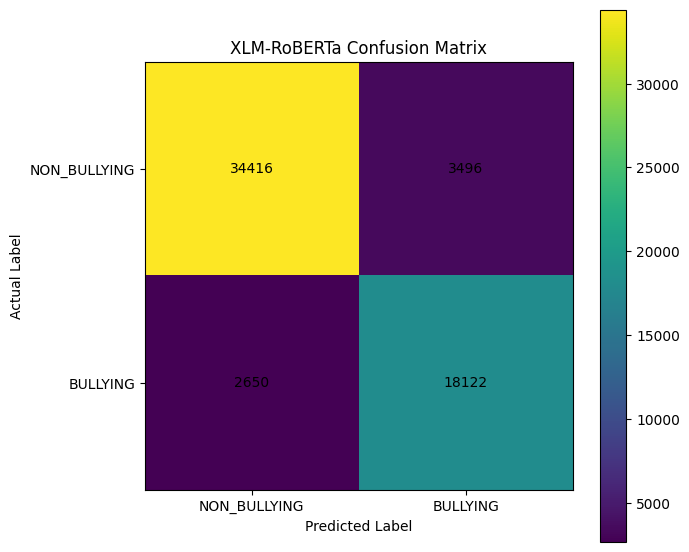

In [ ]:
# ============================================================
# STEP 31: CONFUSION MATRIX + CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt

actual = test_results_df["label"]
predicted = test_results_df["predicted_label"]

# ------------------------------------------------------------
# 1. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(actual, predicted)

print("Confusion Matrix:")
print(cm)

# ------------------------------------------------------------
# 2. Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        actual,
        predicted,
        target_names=[
            "NON_BULLYING",
            "BULLYING"
        ],
        digits=4
    )
)

# ------------------------------------------------------------
# 3. Visualize Confusion Matrix
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("XLM-RoBERTa Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["NON_BULLYING", "BULLYING"]
)

plt.yticks(
    [0, 1],
    ["NON_BULLYING", "BULLYING"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 32: LANGUAGE-WISE PERFORMANCE
# ============================================================

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd

language_results = []

for language in sorted(test_results_df["language"].unique()):

    lang_data = test_results_df[
        test_results_df["language"] == language
    ]

    y_true = lang_data["label"]
    y_pred = lang_data["predicted_label"]

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0
    )

    accuracy = accuracy_score(y_true, y_pred)

    language_results.append({
        "Language": language,
        "Samples": len(lang_data),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

language_results_df = pd.DataFrame(language_results)

print("========== LANGUAGE-WISE PERFORMANCE ==========\n")
print(
    language_results_df.to_string(
        index=False,
        formatters={
            "Accuracy": "{:.4f}".format,
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1": "{:.4f}".format
        }
    )
)

========== LANGUAGE-WISE PERFORMANCE ==========

 Language  Samples Accuracy Precision Recall     F1
  English    18422   0.9589    0.8126 0.8558 0.8336
    Hindi    10525   0.8589    0.8492 0.9094 0.8783
  Kannada     7144   0.8606    0.8456 0.8538 0.8496
Malayalam     6430   0.8767    0.8135 0.8614 0.8367
    Tamil    10171   0.8543    0.7913 0.8315 0.8109
   Telugu     5992   0.8945    0.9077 0.8923 0.9000


In [ ]:
# ============================================================
# STEP 33: ERROR ANALYSIS
# ============================================================

# False Positives
false_positives = test_results_df[
    (test_results_df["label"] == 0) &
    (test_results_df["predicted_label"] == 1)
]

# False Negatives
false_negatives = test_results_df[
    (test_results_df["label"] == 1) &
    (test_results_df["predicted_label"] == 0)
]

print("========== ERROR SUMMARY ==========")
print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

print("\n========== FALSE POSITIVE EXAMPLES ==========")
print(
    false_positives[
        ["text", "label", "predicted_label", "language"]
    ].head(10).to_string(index=False)
)

print("\n========== FALSE NEGATIVE EXAMPLES ==========")
print(
    false_negatives[
        ["text", "label", "predicted_label", "language"]
    ].head(10).to_string(index=False)
)

========== ERROR SUMMARY ==========
False Positives: 3496
False Negatives: 2650

========== FALSE POSITIVE EXAMPLES ==========
                                                                                                                                                                     text  label  predicted_label  language
                                                                                           When my Chutiya best friend talks about Something good https://t.co/trbQ3WDmnz      0                1   English
                                                                        കുറ്റം പറയേണ്ട വീഡിയോ അത്രയൊ ഇതിൽ ഉണ്ട് അതിനു നല്ലത് പറയും നല്ലതിനെ മോശമാക്കി പറയും ബല്ലാത്ത ജാതി      0                1 Malayalam
                                                                                                                             ಒಂದು ದೊಡ ಕರಡಿ ಇದೇ,, ಅದ್ರಲ್ಲೂ ಒಂದು ಹಂದಿ ಇದೇ,,      0                1   Kannada
ಕಾವಲಿಗಿಲ್ಲದ ಹೋಲ ಕಳ್ಳರ ಪಾಲು ಥೂ ಇನ್ನೂ ಎಷ್ಟೋ ಬಡಜನರ ಹೊಟ್ಟೆ ಮೇ

In [ ]:
# ============================================================
# STEP 34: LANGUAGE-WISE ERROR ANALYSIS
# ============================================================

import pandas as pd

language_error_results = []

for language in sorted(test_results_df["language"].unique()):

    lang_data = test_results_df[
        test_results_df["language"] == language
    ]

    actual = lang_data["label"]
    predicted = lang_data["predicted_label"]

    tn = ((actual == 0) & (predicted == 0)).sum()
    fp = ((actual == 0) & (predicted == 1)).sum()
    fn = ((actual == 1) & (predicted == 0)).sum()
    tp = ((actual == 1) & (predicted == 1)).sum()

    language_error_results.append({
        "Language": language,
        "Samples": len(lang_data),
        "True_Negative": tn,
        "False_Positive": fp,
        "False_Negative": fn,
        "True_Positive": tp
    })

language_error_df = pd.DataFrame(language_error_results)

print("========== LANGUAGE-WISE ERROR ANALYSIS ==========\n")
print(language_error_df.to_string(index=False))

print("\n========== TOTALS ==========")
print("True Negatives :", language_error_df["True_Negative"].sum())
print("False Positives:", language_error_df["False_Positive"].sum())
print("False Negatives:", language_error_df["False_Negative"].sum())
print("True Positives  :", language_error_df["True_Positive"].sum())

========== LANGUAGE-WISE ERROR ANALYSIS ==========

 Language  Samples  True_Negative  False_Positive  False_Negative  True_Positive
  English    18422          15765             438             320           1899
    Hindi    10525           3683             951             534           5357
  Kannada     7144           3334             514             482           2814
Malayalam     6430           3605             466             327           2032
    Tamil    10171           5512             838             644           3177
   Telugu     5992           2517             289             343           2843

========== TOTALS ==========
True Negatives : 34416
False Positives: 3496
False Negatives: 2650
True Positives  : 18122


In [ ]:
# ============================================================
# STEP 35: SAVE FINAL TRAINED MODEL
# ============================================================

FINAL_MODEL_DIR = "/content/drive/MyDrive/Cyberbullying_Project/xlm_roberta_cyberbullying"

model.save_pretrained(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)

print("Final model saved successfully!")
print("Location:", FINAL_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final model saved successfully!
Location: /content/drive/MyDrive/Cyberbullying_Project/xlm_roberta_cyberbullying


In [ ]:
# ============================================================
# STEP 36: CREATE PREDICTION FUNCTION
# ============================================================

import torch
import torch.nn.functional as F

def predict_text(text):
    """
    Predict whether a text is bullying or non-bullying.
    """

    # Tokenize input
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    # Move inputs to the same device as the model
    device = next(model.parameters()).device
    inputs = {key: value.to(device) for key, value in inputs.items()}

    # Prediction
    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    # Convert logits to probabilities
    probabilities = F.softmax(outputs.logits, dim=-1)

    predicted_label = torch.argmax(probabilities, dim=-1).item()
    confidence = probabilities[0][predicted_label].item()

    label_name = model.config.id2label[predicted_label]

    print("Text:", text)
    print("Prediction:", label_name)
    print(f"Confidence: {confidence * 100:.2f}%")

    return label_name, confidence

In [ ]:
# ============================================================
# STEP 36B: TEST THE PREDICTION FUNCTION
# ============================================================

predict_text("You are stupid and nobody likes you")

Text: You are stupid and nobody likes you
Prediction: BULLYING
Confidence: 95.44%


('BULLYING', 0.9544354677200317)

In [ ]:
# ============================================================
# STEP 37: MULTILINGUAL PREDICTION TEST
# ============================================================

test_examples = {
    "English": "You are stupid and nobody likes you",
    "Hindi": "तुम बहुत बेवकूफ हो",
    "Tamil": "நீ ஒரு முட்டாள்",
    "Telugu": "నువ్వు చాలా మూర్ఖుడివి",
    "Kannada": "ನೀನು ತುಂಬಾ ಮೂರ್ಖ",
    "Malayalam": "നീ ഒരു മണ്ടനാണ്"
}

print("========== MULTILINGUAL TEST ==========\n")

for language, text in test_examples.items():

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    device = next(model.parameters()).device
    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = F.softmax(outputs.logits, dim=-1)

    predicted_label = torch.argmax(
        probabilities,
        dim=-1
    ).item()

    confidence = probabilities[0][predicted_label].item()

    label_name = model.config.id2label[predicted_label]

    print(f"{language:10s}: {label_name:15s} "
          f"({confidence * 100:.2f}%)")

========== MULTILINGUAL TEST ==========

English   : BULLYING        (95.44%)
Hindi     : BULLYING        (99.42%)
Tamil     : BULLYING        (97.96%)
Telugu    : BULLYING        (75.26%)
Kannada   : BULLYING        (64.25%)
Malayalam : BULLYING        (95.07%)


In [ ]:
# ============================================================
# STEP 39: V2 TOKENIZATION - 256 TOKENS
# ============================================================

from datasets import Dataset

MAX_LENGTH_V2 = 256

# Load the final training and validation files
train_df_v2 = pd.read_csv(
    f"{DATA_DIR}/train_final.csv"
)

val_df_v2 = pd.read_csv(
    f"{DATA_DIR}/validation_final.csv"
)

print("Training rows:", len(train_df_v2))
print("Validation rows:", len(val_df_v2))

# Convert to Hugging Face datasets
train_dataset_v2 = Dataset.from_pandas(
    train_df_v2[["text", "label"]],
    preserve_index=False
)

val_dataset_v2 = Dataset.from_pandas(
    val_df_v2[["text", "label"]],
    preserve_index=False
)

# Tokenization function
def tokenize_v2(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH_V2
    )

# Tokenize
train_dataset_v2 = train_dataset_v2.map(
    tokenize_v2,
    batched=True,
    batch_size=1000
)

val_dataset_v2 = val_dataset_v2.map(
    tokenize_v2,
    batched=True,
    batch_size=1000
)

print("\nV2 tokenization completed!")
print("Max length:", MAX_LENGTH_V2)
print("Training examples:", len(train_dataset_v2))
print("Validation examples:", len(val_dataset_v2))

Training rows: 317174
Validation rows: 58688


Map:   0%|          | 0/317174 [00:00<?, ? examples/s]

Map:   0%|          | 0/58688 [00:00<?, ? examples/s]


V2 tokenization completed!
Max length: 256
Training examples: 317174
Validation examples: 58688


In [ ]:
# ============================================================
# STEP 40: CREATE XLM-ROBERTA V2 MODEL
# ============================================================

from transformers import AutoModelForSequenceClassification

model_v2 = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=2,
    id2label={
        0: "NON_BULLYING",
        1: "BULLYING"
    },
    label2id={
        "NON_BULLYING": 0,
        "BULLYING": 1
    }
)

print("V2 model created successfully!")
print("Model: XLM-RoBERTa-base")
print("Max token length: 256")
print("Number of labels:", model_v2.config.num_labels)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


V2 model created successfully!
Model: XLM-RoBERTa-base
Max token length: 256
Number of labels: 2


In [ ]:
# ============================================================
# STEP 41: V2 TRAINING CONFIGURATION
# ============================================================

from transformers import TrainingArguments

training_args_v2 = TrainingArguments(
    output_dir="/content/drive/MyDrive/Cyberbullying_Project/xlm_roberta_v2_checkpoints",

    num_train_epochs=4,
    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    gradient_accumulation_steps=2,

    warmup_steps=1000,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    fp16=True,

    logging_steps=100,
    save_total_limit=2,

    report_to="none",
    seed=42
)

print("V2 training configuration created successfully!")
print("Epochs:", training_args_v2.num_train_epochs)
print("Learning rate:", training_args_v2.learning_rate)
print("Max tokens: 256")
print("Train batch size:", training_args_v2.per_device_train_batch_size)
print("FP16:", training_args_v2.fp16)

V2 training configuration created successfully!
Epochs: 4
Learning rate: 2e-05
Max tokens: 256
Train batch size: 8
FP16: True


In [ ]:
from transformers import DataCollatorWithPadding

print("DataCollatorWithPadding imported successfully!")

DataCollatorWithPadding imported successfully!


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

print("Tokenizer loaded successfully!")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Tokenizer loaded successfully!


In [ ]:
# ============================================================
# RECREATE V2 DATASETS
# ============================================================

import pandas as pd
from datasets import Dataset

DATA_DIR = "/content/drive/MyDrive/Cyberbullying_Project"

train_df_v2 = pd.read_csv(f"{DATA_DIR}/train_final.csv")
val_df_v2 = pd.read_csv(f"{DATA_DIR}/validation_final.csv")

train_dataset_v2 = Dataset.from_pandas(train_df_v2)
val_dataset_v2 = Dataset.from_pandas(val_df_v2)

def tokenize_v2(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=256
    )

train_dataset_v2 = train_dataset_v2.map(
    tokenize_v2,
    batched=True
)

val_dataset_v2 = val_dataset_v2.map(
    tokenize_v2,
    batched=True
)

print("V2 datasets recreated successfully!")
print("Training rows:", len(train_dataset_v2))
print("Validation rows:", len(val_dataset_v2))

Map:   0%|          | 0/317174 [00:00<?, ? examples/s]

Map:   0%|          | 0/58688 [00:00<?, ? examples/s]

V2 datasets recreated successfully!
Training rows: 317174
Validation rows: 58688


In [ ]:
# ============================================================
# RECREATE V2 MODEL
# ============================================================

from transformers import AutoModelForSequenceClassification

model_v2 = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=2,
    id2label={
        0: "NON_BULLYING",
        1: "BULLYING"
    },
    label2id={
        "NON_BULLYING": 0,
        "BULLYING": 1
    }
)

print("V2 model created successfully!")

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


V2 model created successfully!


In [ ]:
# ============================================================
# RECREATE V2 TRAINING ARGUMENTS
# ============================================================

from transformers import TrainingArguments

training_args_v2 = TrainingArguments(
    output_dir="/content/drive/MyDrive/Cyberbullying_Project/xlm_roberta_v2_checkpoints",

    num_train_epochs=4,
    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,

    warmup_steps=1000,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    fp16=True,

    logging_steps=100,
    save_total_limit=2,

    report_to="none",
    seed=42
)

print("V2 training arguments recreated successfully!")
print("Epochs: 4")
print("Learning rate: 2e-5")
print("Batch size: 8")
print("Gradient accumulation: 2")
print("FP16: enabled")
print("Early stopping: 1 epoch patience")

V2 training arguments recreated successfully!
Epochs: 4
Learning rate: 2e-5
Batch size: 8
Gradient accumulation: 2
FP16: enabled
Early stopping: 1 epoch patience


In [ ]:
# ============================================================
# RECREATE METRICS FUNCTION
# ============================================================

import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("compute_metrics recreated successfully!")

compute_metrics recreated successfully!


In [ ]:
# ============================================================
# STEP 42: CREATE V2 TRAINER
# ============================================================

from transformers import Trainer, EarlyStoppingCallback

data_collator_v2 = DataCollatorWithPadding(
    tokenizer=tokenizer
)

trainer_v2 = Trainer(
    model=model_v2,
    args=training_args_v2,

    train_dataset=train_dataset_v2,
    eval_dataset=val_dataset_v2,

    data_collator=data_collator_v2,
    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=1
        )
    ]
)

print("V2 Trainer created successfully!")
print("Early stopping patience: 1 epoch")
print("Ready for V2 training.")

V2 Trainer created successfully!
Early stopping patience: 1 epoch
Ready for V2 training.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

DATA_DIR = "/content/drive/MyDrive/Cyberbullying_Project"

print(os.path.exists(DATA_DIR))
print(os.listdir(DATA_DIR))

True
['multilingual_dataset.csv', 'english_clean.csv', 'multilingual_dataset_with_synthetic.csv', 'CyberbullyX-63K.xlsx', 'hindi_val.csv', 'hindi_test.csv', 'malyalam_train.csv', 'README.md', 'malyalam_val.csv', 'kannada_val.csv', 'kannada_test.csv', 'kannada_train.csv', 'malyalam_test.csv', 'tamil_test.csv', 'hindi_train.csv', 'telugu_test.csv', 'tamil_val.csv', 'telugu_train.csv', 'telugu_val.csv', 'tamil_train.csv', 'train_final.csv', 'validation_final.csv', 'test_final.csv', 'xlm_roberta_cyberbullying', 'xlm_roberta_checkpoints', 'xlm_roberta_v2_checkpoints']


In [ ]:
import os

V2_DIR = "/content/drive/MyDrive/Cyberbullying_Project/xlm_roberta_v2_checkpoints"

print("V2 checkpoint folder exists:", os.path.exists(V2_DIR))

if os.path.exists(V2_DIR):
    print("\nContents:")
    for item in sorted(os.listdir(V2_DIR)):
        print("-", item)

V2 checkpoint folder exists: True

Contents:


In [ ]:
import os

V1_DIR = "/content/drive/MyDrive/Cyberbullying_Project/xlm_roberta_cyberbullying"

print("V1 model folder exists:", os.path.exists(V1_DIR))

if os.path.exists(V1_DIR):
    print("\nV1 model files:")
    for item in sorted(os.listdir(V1_DIR)):
        print("-", item)

V1 model folder exists: True

V1 model files:
- config.json
- model.safetensors
- tokenizer.json
- tokenizer_config.json


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available")

CUDA available: True
GPU: Tesla T4


In [ ]:
print("V2 READY CHECK")
print("=" * 40)

print("Tokenizer:", tokenizer is not None)
print("Train dataset:", len(train_dataset_v2))
print("Validation dataset:", len(val_dataset_v2))
print("Model:", type(model_v2).__name__)
print("Trainer:", type(trainer_v2).__name__)

import torch
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("=" * 40)
print("Ready to start V2 training!")

V2 READY CHECK
Tokenizer: True
Train dataset: 317174
Validation dataset: 58688
Model: XLMRobertaForSequenceClassification
Trainer: Trainer
CUDA available: True
GPU: Tesla T4
Ready to start V2 training!


In [ ]:
train_result_v2 = trainer_v2.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.518680,0.278270,0.890301,0.853743,0.832088,0.842776
2,0.411591,0.306262,0.887745,0.803145,0.903843,0.850524
3,0.393918,0.318913,0.898821,0.846175,0.872209,0.858995
4,0.411063,0.332912,0.901905,0.854976,0.869943,0.862395


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# STEP 44: V2 TEST EVALUATION
# ============================================================

import pandas as pd
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)
import numpy as np

DATA_DIR = "/content/drive/MyDrive/Cyberbullying_Project"

# Load the same untouched test set used for V1
test_df_v2 = pd.read_csv(f"{DATA_DIR}/test_final.csv")

test_dataset_v2 = Dataset.from_pandas(test_df_v2)

# Tokenize test data with V2's 256-token length
def tokenize_test_v2(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=256
    )

test_dataset_v2 = test_dataset_v2.map(
    tokenize_test_v2,
    batched=True
)

print("Test dataset prepared!")
print("Test rows:", len(test_dataset_v2))

# Predict
predictions_v2 = trainer_v2.predict(test_dataset_v2)

predicted_labels_v2 = np.argmax(
    predictions_v2.predictions,
    axis=-1
)

true_labels_v2 = np.array(test_df_v2["label"])

# Metrics
accuracy_v2 = accuracy_score(true_labels_v2, predicted_labels_v2)

precision_v2, recall_v2, f1_v2, _ = precision_recall_fscore_support(
    true_labels_v2,
    predicted_labels_v2,
    average="binary",
    zero_division=0
)

print("\n========================================")
print("V2 TEST RESULTS")
print("========================================")
print(f"Accuracy : {accuracy_v2:.4f} ({accuracy_v2*100:.2f}%)")
print(f"Precision: {precision_v2:.4f} ({precision_v2*100:.2f}%)")
print(f"Recall   : {recall_v2:.4f} ({recall_v2*100:.2f}%)")
print(f"F1 Score : {f1_v2:.4f} ({f1_v2*100:.2f}%)")

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels_v2, predicted_labels_v2))

print("\nClassification Report:")
print(
    classification_report(
        true_labels_v2,
        predicted_labels_v2,
        target_names=["NON_BULLYING", "BULLYING"],
        digits=4
    )
)

Map:   0%|          | 0/58684 [00:00<?, ? examples/s]

Test dataset prepared!
Test rows: 58684



V2 TEST RESULTS
Accuracy : 0.8998 (89.98%)
Precision: 0.8507 (85.07%)
Recall   : 0.8696 (86.96%)
F1 Score : 0.8601 (86.01%)

Confusion Matrix:
[[34742  3170]
 [ 2708 18064]]

Classification Report:
              precision    recall  f1-score   support

NON_BULLYING     0.9277    0.9164    0.9220     37912
    BULLYING     0.8507    0.8696    0.8601     20772

    accuracy                         0.8998     58684
   macro avg     0.8892    0.8930    0.8910     58684
weighted avg     0.9004    0.8998    0.9001     58684



In [ ]:
# ============================================================
# SAVE V2 FINAL MODEL
# ============================================================

FINAL_MODEL_DIR = "/content/drive/MyDrive/Cyberbullying_Project/xlm_roberta_v2_final"

trainer_v2.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)

print("V2 model saved successfully!")
print("Location:", FINAL_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

V2 model saved successfully!
Location: /content/drive/MyDrive/Cyberbullying_Project/xlm_roberta_v2_final


In [ ]:
# ============================================================
# SAVE V2 TEST RESULTS
# ============================================================

results_v2 = {
    "accuracy": accuracy_v2,
    "precision": precision_v2,
    "recall": recall_v2,
    "f1": f1_v2
}

results_df_v2 = pd.DataFrame([results_v2])

results_path = f"{DATA_DIR}/v2_test_results.csv"
results_df_v2.to_csv(results_path, index=False)

print("V2 test results saved!")
print(results_df_v2)

V2 test results saved!
   accuracy  precision    recall        f1
0  0.899836   0.850711  0.869632  0.860068


In [ ]:
import os

FINAL_MODEL_DIR = "/content/drive/MyDrive/Cyberbullying_Project/xlm_roberta_v2_final"

print("Model folder exists:", os.path.exists(FINAL_MODEL_DIR))
print("\nFiles:")
for f in os.listdir(FINAL_MODEL_DIR):
    print(f)

Model folder exists: True

Files:
config.json
model.safetensors
tokenizer_config.json
tokenizer.json
training_args.bin
